In [1]:
import h5py
import numpy as np

#Open the H5 file in read mode
file_path = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Code\pipes\posterior\exponential\z_2\age_0.03Gyr_exp.h5"

with h5py.File(file_path, "r") as f:
    print("Top-level keys:")
    print(list(f.keys()))

Top-level keys:
['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']


In [8]:
import h5py
import numpy as np

file_path = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Code\pipes\posterior\exponential\z_2\age_0.03Gyr_exp.h5"

with h5py.File(file_path, "r") as f:
    print("Top-level keys:")
    print(list(f.keys()))
    
    # Extract 2D posterior samples
    samples2d = f["samples2d"][:]
    print("samples2d shape:", samples2d.shape)
    #print("First 5 rows:\n", samples2d[:5])

    # Extract median values
    median = f["median"][:]
    print("Median shape:", median.shape)
    print("Median values:", median)

    # Extract confidence intervals
    conf_int = f["conf_int"][:]
    print("Confidence intervals:\n", conf_int)

Top-level keys:
['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']
samples2d shape: (1225, 6)
Median shape: (6,)
Median values: [ 0.09833372  0.36015856 10.25893365  1.76737226  2.94937051 -2.26884896]
Confidence intervals:
 [[ 0.02981626  0.18134144 10.09368396  1.45771925  1.45097085 -2.62261989]
 [ 0.18317518  0.57066731 10.37766062  1.93956885  4.32742669 -2.07939087]]


In [9]:
params = ["Av", "age", "massformed", "metallicity", "tau", "logU"]  # for example

import pandas as pd

df_samples = pd.DataFrame(samples2d, columns=params)
df_samples.head()

,Av,age,massformed,metallicity,tau,logU
0,0.113103,0.437559,10.304103,1.315705,2.910355,-3.656392
1,0.053826,0.625405,10.379559,1.290028,3.002048,-3.681612
2,0.072040,0.415844,10.313883,1.959291,0.622330,-2.663960
3,0.054132,0.687496,10.438755,0.963888,1.650498,-2.163699
4,0.031718,0.335638,10.193478,1.710604,3.387214,-2.503381


In [10]:
import h5py
import glob
import os

folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Code\pipes\posterior\exponential\z_2"
files = sorted(glob.glob(os.path.join(folder, "*.h5")))

for fpath in files:
    with h5py.File(fpath, "r") as f:
        print(f"\nFile: {os.path.basename(fpath)}")
        print("Top-level keys:", list(f.keys()))


File: age_0.00Gyr_exp.h5
Top-level keys: ['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']

File: age_0.00Gyr_exp_.h5
Top-level keys: ['bound_0', 'bound_1', 'bound_10', 'bound_11', 'bound_12', 'bound_13', 'bound_14', 'bound_15', 'bound_16', 'bound_17', 'bound_18', 'bound_19', 'bound_2', 'bound_20', 'bound_21', 'bound_22', 'bound_23', 'bound_24', 'bound_25', 'bound_26', 'bound_27', 'bound_28', 'bound_29', 'bound_3', 'bound_30', 'bound_31', 'bound_32', 'bound_33', 'bound_34', 'bound_35', 'bound_4', 'bound_5', 'bound_6', 'bound_7', 'bound_8', 'bound_9', 'sampler']

File: age_0.01Gyr_exp.h5
Top-level keys: ['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']

File: age_0.01Gyr_exp_.h5
Top-level keys: ['bound_0', 'bound_1', 'bound_10', 'bound_11', 'bound_12', 'bound_13', 'bound_14', 'bound_15', 'bound_16', 'bound_17', 'bound_18', 'bound_19', 'bound_2', 'bound_20', 'bound_21', 'bound_22', 'bound_23', 'bound_24', 'bound_25', 'bound_26', 'bound_27', 'bound_28', 'bound

In [ ]:
import h5py
import glob
import os
import numpy as np
import pandas as pd

folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Code\pipes\posterior\exponential\z_2"
files = sorted(glob.glob(os.path.join(folder, "*.h5")))

params = ["Av", "age", "massformed", "metallicity", "tau", "logU"]

data_list = []

for fpath in files:
    fname = os.path.basename(fpath)
    
    # Skip the files with "_" at the end of the name
    if fname.endswith("_.h5"):
        continue
    
    age_label = fname.replace(".h5", "")
    
    with h5py.File(fpath, "r") as f:
        median = f['median'][:]       # shape (6,)
        conf_int = f['conf_int'][:]   # shape (2,6), lower and upper bounds
    
    age_value = float(age_label.split("_")[1].replace("Gyr",""))

    row = {
        "age": age_value
    }
    for i, p in enumerate(params):
        row[f"{p}_median"] = median[i]
        row[f"{p}_lower"] = conf_int[0, i]
        row[f"{p}_upper"] = conf_int[1, i]
    
    data_list.append(row)

df = pd.DataFrame(data_list)
df = df.sort_values("age")  # sort by age

print(df)

     age  Av_median  Av_lower  Av_upper  age_median  age_lower  age_upper  \
0   0.00   0.208033  0.186021  0.230009    0.001993   0.001286   0.002975   
1   0.01   0.078558  0.028866  0.126446    0.095580   0.054812   0.155906   
2   0.02   0.089849  0.032032  0.150227    0.152931   0.083385   0.247524   
3   0.03   0.098334  0.029816  0.183175    0.360159   0.181341   0.570667   
4   0.04   0.098533  0.035391  0.179669    0.459104   0.262542   0.678974   
5   0.05   0.132540  0.065827  0.218146    0.504320   0.301740   0.770042   
6   0.06   0.222420  0.124407  0.351682    0.481274   0.271924   0.752773   
7   0.07   0.211939  0.118803  0.365015    0.497037   0.291816   0.777794   
8   0.08   0.311411  0.198076  0.451856    0.570008   0.368593   0.842597   
9   0.09   0.433179  0.303501  0.528603    0.714312   0.443706   0.902810   
10  0.10   0.423621  0.305938  0.528069    0.706617   0.447989   0.906794   
11  0.20   0.521458  0.376202  0.627930    0.728478   0.486597   0.908637   

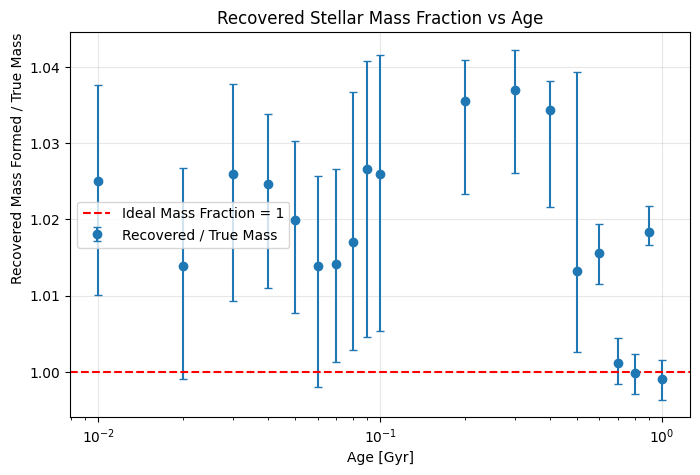

In [20]:
import matplotlib.pyplot as plt

true_mass = 10.0

ages = df['age']

# Extract recovered massformed median and confidence intervals
mass_median = df['massformed_median']
mass_lower = df['massformed_lower']
mass_upper = df['massformed_upper']

# Convert to fraction of true mass
mass_frac_median = mass_median / true_mass
mass_frac_lower = mass_lower / true_mass
mass_frac_upper = mass_upper / true_mass

# Compute lower and upper error bars for plotting
err_lower = mass_frac_median - mass_frac_lower
err_upper = mass_frac_upper - mass_frac_median

plt.figure(figsize=(8,5))
plt.errorbar(ages, mass_frac_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered / True Mass')
plt.axhline(1.0, color='r', linestyle='--', label='Ideal Mass Fraction = 1')
plt.xlabel("Age [Gyr]")
plt.ylabel("Recovered Mass Formed / True Mass", loc = 'top')
plt.title("Recovered Stellar Mass Fraction vs Age")
plt.xscale('log')  # Set y-axis to logarithmic scale
plt.legend()
plt.grid(alpha=0.3)
plt.show()

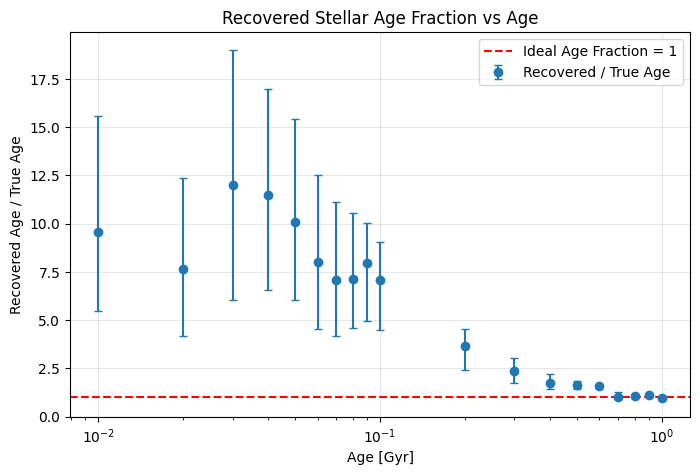

In [28]:
import matplotlib.pyplot as plt

ages = df['age']

# Extract recovered massformed median and confidence intervals
age_median = df['age_median']
age_lower = df['age_lower']
age_upper = df['age_upper']

# Convert to fraction of true mass
age_frac_median = age_median / ages
age_frac_lower = age_lower / ages
age_frac_upper = age_upper / ages

# Compute lower and upper error bars for plotting
err_lower = age_frac_median - age_frac_lower
err_upper = age_frac_upper - age_frac_median

plt.figure(figsize=(8,5))
plt.errorbar(ages, age_frac_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered / True Age')
plt.axhline(1.0, color='r', linestyle='--', label='Ideal Age Fraction = 1')
plt.xlabel("Age [Gyr]")
plt.ylabel("Recovered Age / True Age")
plt.xscale('log')  # Set y-axis to logarithmic scale
plt.title("Recovered Stellar Age Fraction vs Age")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

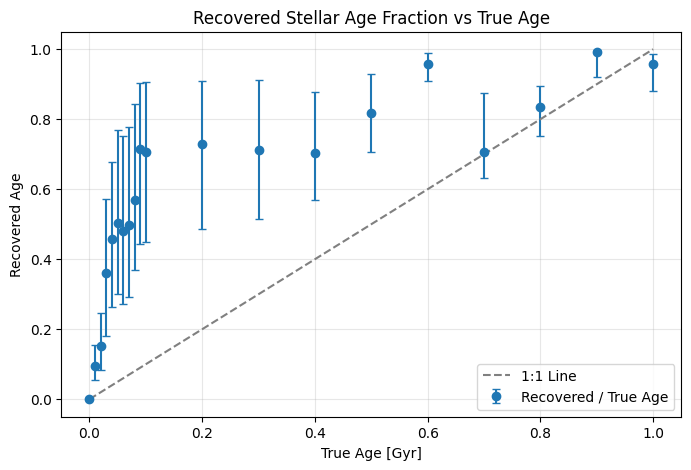

In [ ]:
import matplotlib.pyplot as plt

ages = df['age']

# Extract recovered massformed median and confidence intervals
age_median = df['age_median']
age_lower = df['age_lower']
age_upper = df['age_upper']

# Convert to fraction of true mass
age_frac_median = age_median / ages
age_frac_lower = age_lower / ages
age_frac_upper = age_upper / ages

# Compute lower and upper error bars for plotting
err_lower = age_median - age_lower
err_upper = age_upper - age_median

plt.figure(figsize=(8,5))
plt.errorbar(ages, age_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered / True Age')
plt.xlabel("True Age [Gyr]")
plt.ylabel("Recovered Age")
plt.plot(ages, ages, linestyle='--', color='gray', label='1:1 Line') 
plt.title("Recovered Stellar Age Fraction vs True Age")
plt.legend()
plt.grid(alpha=0.3)
plt.show()